In [17]:
from matplotlib.pyplot import *
from numpy import *
import pandas as pd

[4.47761194e+14 5.08474576e+14 5.29100529e+14 5.76923077e+14
 6.25000000e+14]
1.414213562373085


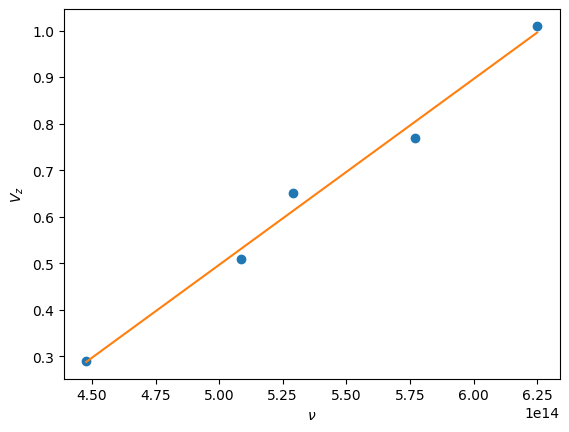

In [57]:
data = [
    #wavelength,Vz
    [670e-9, .29],
    [590e-9, .51],
    [567e-9, .65],
    [520e-9, .77],
    [480e-9,1.01]
]
data = array(data)
c = 3e8
data = data.T
data[0] = c/data[0]
print(data[0])
data = data.T
plot(data[:,0],data[:,1],'o')
X = array([[data[i][0],1] for i in range(len(data))])
y = data[:,1]
XTX = X.T @ X
I = identity(XTX.shape[0])
PI = linalg.inv(XTX) @ X.T
m,C = dot(PI,y)
freq = data[:,0]
ypred = m*freq + C
plot(freq,ypred)
xlabel(r"$\nu$")
ylabel("$V_z$")

In [37]:
m,C

(3.611916330370437e-15, -1.292645913231153)

In [55]:
err = ypred - y
rmse = mean(err**2) ** 0.5
rmse

0.025094370979817194

In [56]:
qe = 1.6e-19
h = m*qe
h #Js

6.3906118788177325e-34

In [22]:
mexp = sum(freq*(y - C))/sum(freq**2)
Cexp = mean(y - m*freq)
mexp,m,C,Cexp

(2.764704079728507e-15,
 2.7647040797285086e-15,
 -0.8315795962402818,
 -0.8398953922026857)

In [23]:
sigh = qe*rmse/(sum(freq**2))**0.5
sigphi = rmse
print("standard deviation of h is",qe*rmse/(sum(freq**2))**0.5)
print("standard deviation of Phi is",sigphi)

standard deviation of h is 1.0412419336578905e-35
standard deviation of Phi is 0.07869951308517888


In [24]:
hlis = linspace(0.98*h,1.02*h,1000)
ph = exp(-(hlis - h)**2/(2*sigh**2))/((2*pi)**0.5 * sigh)
plot(hlis,ph)
xticks([h,h-sigh,h+sigh],labels=[r"$\bar h$",r"$\bar h - \sigma_h$",r"$\bar h + \sigma_h$"])
title(
r"$\bar h = " + str(round(h*1e34,4)) + r"\times 10^{-34} \text{Js}$" + "\n" +
r"$\sigma_h = " + str(round(sigh*1e36,4))+ r"\times 10^{-36} \text{Js}$"
)
ylabel(r"$ P(  h \ |\ X,\Phi) $")

Text(0, 0.5, '$ P(  h \\ |\\ X,\\Phi) $')

Error in callback <function _draw_all_if_interactive at 0x78d2e4643130> (for post_execute):


ValueError: 
\bar h = 4.4235\times 10^{-34} \text{Js}
                               ^
ParseFatalException: Expected token, found '\'  (at char 31), (line:1, col:32)

ValueError: 
\bar h = 4.4235\times 10^{-34} \text{Js}
                               ^
ParseFatalException: Expected token, found '\'  (at char 31), (line:1, col:32)

<Figure size 640x480 with 1 Axes>

In [25]:
phi=-C
philis = linspace(0.9*phi,1.1*phi,1000)
pphi = exp(-(philis - phi)**2/(2*sigphi**2))/((2*pi)**0.5 * sigphi)
plot(philis,pphi)
xticks([phi,phi-sigphi,phi+sigphi],labels=[r"$\bar \Phi$",r"$\bar \Phi - \sigma_\Phi$",r"$\bar \Phi + \sigma_\Phi$"])
title(
r"$\bar \Phi = " + str(round(phi,4)) + r"\text{ V}$" + "\n" +
r"$\sigma_\Phi = " + str(round(sigphi,4))+ r"\text{ V}$"
)
ylabel(r"$ P(  \Phi \ |\ X,h) $")

Text(0, 0.5, '$ P(  \\Phi \\ |\\ X,h) $')

Error in callback <function _draw_all_if_interactive at 0x78d2e4643130> (for post_execute):


ValueError: 
\bar \Phi = 0.8316\text{ V}
                  ^
ParseFatalException: Expected token, found '\'  (at char 18), (line:1, col:19)

ValueError: 
\bar \Phi = 0.8316\text{ V}
                  ^
ParseFatalException: Expected token, found '\'  (at char 18), (line:1, col:19)

<Figure size 640x480 with 1 Axes>

In [26]:
pairs = [[(freq[i],freq[j],y[i],y[j]) for i in range(j)] for j in range(len(freq))]
pairs

[[],
 [(447761194029850.7, 508474576271186.5, 0.29, 0.51)],
 [(447761194029850.7, 529100529100529.06, 0.29, 0.65),
  (508474576271186.5, 529100529100529.06, 0.51, 0.65)],
 [(447761194029850.7, 576923076923076.9, 0.29, 0.77),
  (508474576271186.5, 576923076923076.9, 0.51, 0.77),
  (529100529100529.06, 576923076923076.9, 0.65, 0.77)],
 [(447761194029850.7, 625000000000000.0, 0.29, 1.01),
  (508474576271186.5, 625000000000000.0, 0.51, 1.01),
  (529100529100529.06, 625000000000000.0, 0.65, 1.01),
  (576923076923076.9, 625000000000000.0, 0.77, 1.01)]]

In [27]:
P = []
for p in pairs: P.extend(p)

In [28]:
LCEh = 0
LCEPhi = 0
LC_I = 1e-9 #A
LC_V = 0.01 #V
hpair = 0
phipair = 0
N = len(P)
for p in P:
    nu1,nu2,V1,V2 = p
    LCEPhi += 0.5 * LC_V * (nu1 + nu2) / abs(nu1 - nu2)
    LCEh += qe * LC_V/abs(nu2-nu1)
    hpair += qe * (V1-V2)/(nu1-nu2)
    phipair += (V1*nu2 - V2*nu1)/(nu2-nu1)
LCEPhi /= N
LCEh /= N
hpair /= N
phipair /= N
LCEh,LCEPhi,hpair,phipair


(2.655384172284132e-35,
 0.08889828969686817,
 6.7136362929758555e-34,
 -1.6085612513329253)

Text(0, 0.5, '$V_z$')

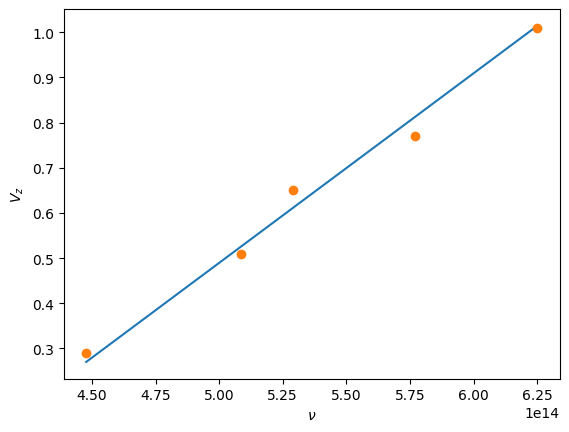

In [29]:
m = hpair / qe
freq = data[:,0]
ypred = m*freq + phipair
plot(freq,ypred)
plot(data[:,0],data[:,1],'o')
xlabel(r"$\nu$")
ylabel("$V_z$")

In [30]:
rmse_pair = mean((ypred - data[:,1])**2)**0.5
rmse_pair,rmse

(0.02789730980234128, 0.07869951308517888)

In [31]:
sigLC = LC_V/12**0.5
sighLC = qe*sigLC/(sum(freq**2))**0.5
sigphiLC = sigLC
print("standard deviation of h is",sighLC)
print("standard deviation of Phi is",sigphiLC)

standard deviation of h is 3.819345807376561e-37
standard deviation of Phi is 0.002886751345948129


### Part 2

In [32]:
df = pd.read_csv("Part2.csv")
df.plot("r","I")

FileNotFoundError: [Errno 2] No such file or directory: 'Part2.csv'

In [ ]:
df["1/r^2"] = df["r"]**-2

In [ ]:
df.plot("1/r^2","I")
X = array([[df["1/r^2"][i],1] for i in range(len(df['r']))])
y = df["I"].values
pI = linalg.inv(X.T @ X) @ X.T
m,c = dot(pI,y)
rm2 = df["1/r^2"].values
ypred = m*rm2 + c
plot(rm2,ypred)
xlabel(r"$r^{-2} \ (\text{m}^{-2})$")
ylabel(r"$I (\mu\text{A})$")


In [ ]:
df

In [ ]:
mse = mean((y - ypred)**2)
rmse = mse**0.5
m,c,mse